# __ML in der Logistik__
# Exercise 06 - Clustering

__Goal__: Understand two basic algorithms for clustering, understand how the distance metrics affect the clustering and how to transform the data space to perform better clustering.


__Data and application__: The dataset contains the mean SOG and Duration information for 3376 trips on the 4 usual routes. We want to cluster the trips according to their mean SOG and their duration.



### Contents

* [1 Theory: Simple K Means algorithm (15 min)](#t1)
* [2 Practice: distance metrics, transformation of the space](#t2)
    * [2.1 The KMeans algorithm (10 min)](#t21)
    * [2.2 Distance metrics (15 min)](#t22)
    * [2.3 Transformation of the space (15 min)](#t23)
    * [2.4 Hierarchical clustering: AgglomerativeClustering (10 min)](#t24)

## 1 Theory: K-Means algorithm (15 min) <a class="anchor" id="t1"></a>

The K-Means algorithm (with $n$ the number of clusters, which has to be chosen by the data scientist):
* Initialize n points randomly: they are the starting point for the center of each cluster.
* Compute the distance between each datapoint and the center of the clusters: the smallest distance gives the cluster to which the datapoint belongs.
* Recompute the centers of the clusters by taking the mean of all the datapoints belonging to it.
* Repeat the steps until the stopping criterion is reached (number of iterations, no movement of the center between two steps, ...).

You are given this dataset, containing 5 points:

![text](06-dataset-1.PNG)

Apply the K-Means algorithm on this dataset, with the following conditions:
* We initialize 2 starting points for the clusters, which are: $C1 = (6; 1)$ and $C2 = (2; 6)$
* We use the Euclidean distance to compute the distance between the points and the centers
* The algorithm stops when the belonging of each point doesn't change after re-calculating the position of the centers of the clusters

(Hint: draw a table with, for each iteration, the position of the 2 centers and the cluster's assigment of each
point.)

__For each point, give the final belonging in a cluster (__ ``'C1'`` __or__ ``'C2'`` __). (1 point / point).__

In [ ]:
# Final belonging of each point (strings)

t1_P1 = 
t1_P2 = 
t1_P3 = 
t1_P4 = 
t1_P5 = 

## 2 Practice: distance metrics, transformation of the space <a class="anchor" id="t1"></a>

### 2.1 The KMeans algorithm (10 min) <a class="anchor" id="t21"></a>

Import the dataset ``06-clustering.csv``. The dataset contains the SOG and Duration attributes for 3376 trips on the 4 usual routes. We use only 2 attributes in this exercise, for visualization purpose.

In [1]:
# Load the dataset

import pandas as pd
df = pd.read_csv('06-clustering.csv', na_values = '?')

Visualize the dataset, using the function given here.

In [19]:
# Visualize function (just execute this code)
import numpy as np

def plot_2att(df, att1, att2):
    import matplotlib.pyplot as plt
    '''
    Function for plotting two attributes colored by a class attribute
    
    df: dataframe, the dataset
    att1, att2: strings, the names of the two attributes to be plotted
    '''
    
    df2 = df.copy()

    plt.figure(figsize=(12,8))
    plt.plot(np.asarray(df2[att1]), np.asarray(df2[att2]), 'x') # use np.asarray in case one of the attribute is
                                                          # categorical, i[0] would return a category and not an array
    title = att1 + ' vs. ' + att2
    plt.title(title)

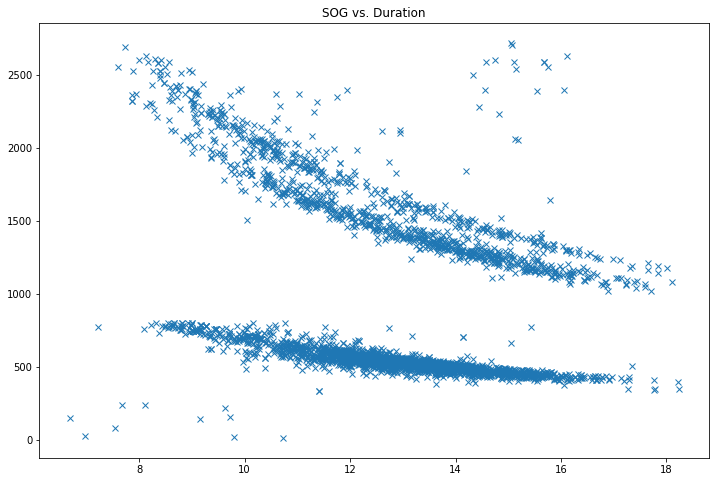

In [20]:
# Visualize the dataset



__Looking at the dataset, how many clusters can we identify? (1 point)__

__Is the frontier between the clusters clearly defined? (1 point)__ (``0`` for no, ``1`` for yes)

In [ ]:
# Number of clusters and definition of the frontier (integers)

t21_clusters = 
t21_frontier = 

Now we want to build a K-Means clustering model, using the function ``KMeans`` from the library ``sklearn``.

Before we do so, we want to normalize the dataset. Every attribute will be scaled to a [0,1] range and then will be considered equally for clustering.

__Execute the following function and use it to normalize the 2 attributes of the dataset.__

In [56]:
# Define normalize function

def normalize_01(att):
    att_norm = att.copy()
    if att_norm.max() - att_norm.min() == 0: # constant column
        att_norm = 0.5
    else:
        att_norm = (att_norm - att_norm.min()) / (att_norm.max() - att_norm.min())
    return att_norm

In [57]:
# Normalize the 2 attributes



This function is used a bit differently than what we are used to, because this time it is an unsupervised machine learning technique: it means, we do not need a training and testing dataset. We just feed the data into the model and it splits the datapoints into different clusters. Once fitted, the ``KMeans`` instance contains different attributes, the ``.labels_`` one returns a list with the label for each datapoint. The documentation of the function can be found here: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html.

With this function, the user needs to precise the number of clusters into which the data should be clustered. __Assign an integer to ``n``, corresponding of the number of clusters you replied in the previous question.__

In [58]:
from sklearn.cluster import KMeans

n = 

kmeans = KMeans(n_clusters = n, random_state = 1).fit(df)

Now that we built the model and assigned a cluster to each datapoint, we want to visualize it. The following function allows you to plot the dataset with the cluster assignment for each datapoint. __Just execute the code and plot the result.__

In [26]:
# Visualize function (just execute this code)
import numpy as np

def plot_2att_clusters(df, att1, att2, clust):
    import matplotlib.pyplot as plt
    '''
    Function for plotting two attributes colored by a class attribute
    
    df: dataframe, the dataset
    att1, att2: strings, the names of the two attributes to be plotted
    clas_att: string, the name of the attribute used for coloration !! must be categorical or object
    '''
    
    df2 = df.copy()
    
    df2['cluster'] = clust
    
    # list_clas: list of the values of the class attribute
    list_clas = np.unique(clust)

    # Create one list for each clas_att value in the array tuples
    tuples = []
    for i in list_clas:
        tuples.append(
            [df2.loc[df2['cluster'] == i][att1].values, df2.loc[df2['cluster'] == i][att2].values]
        )

    plt.figure(figsize=(12,8))
    j = 0
    for i in tuples:
        label = 'cluster ' + str(list_clas[j])
        j = j + 1
        plt.plot(np.asarray(i[0]), np.asarray(i[1]), 'x', label = label) # use np.asarray in case one of the attribute is
                                                          # categorical, i[0] would return a category and not an array
    plt.legend(loc = 'upper left')
    title = att1 + ' vs. ' + att2 + ' KMeans clustering'
    plt.title(title)

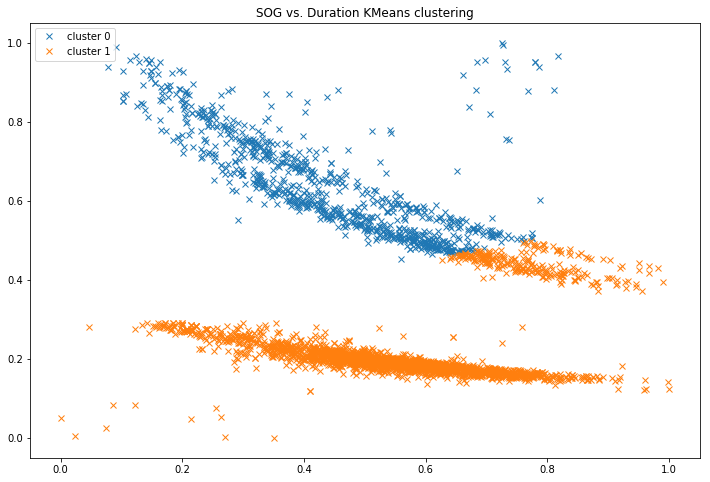

In [59]:
# Plot the result

plot_2att_clusters(df, 'SOG', 'Duration', kmeans.labels_)

Try to change the value of ``n`` and see how the clustering changes.

### 2.2 Distance metrics (15 min) <a class="anchor" id="t22"></a>

In this section, we will work theoretically. Admit we use the same dataset as the one from the previous task. We build a clustering model using a K-Means method, but we change the way the distance is calculated to cluster the datapoints.

We use once the Euclidean distance and once the Manhattan distance. The results of both models are the following:

![text](06-euclidean.png)

![text](06-manhattan.png)

_Explain how the Manhattan distance is calculated._

_With the Euclidean distance, are the clusters correctly identified? What do you think causes this?_

_What happens when we switch to the Manhattan distance?_

_Explain the position of the data centroid in the second graph._

_From the shape of the clusters and the graphs, explain why the K-means algorithm using the Manhattan distance gives better results than the Euclidean distance on this dataset._

_In general, when do you think it makes more sense to use the Manhattan distance for clustering? (Hint: Euclidean and Manhattan distance can be compared the same way that the RMSE and the MAE are. Taking the RMSE error leads the extreme values to have more influence on the measure.)_

### 2.3 Transformation of the space (15 min) <a class="anchor" id="t23"></a>

In machine learning, it is a common trick to transform the data in order to make decisions easier (the kernel trick used in SVM for instance, is a transformation of the data). With clustering, it is also possible to transform the data in order for the algorithm to identify the clusters better.

A first option of transformation is to select the attributes considered for clustering. For that, __change the value of ``x`` in the following code cell to use only some attributes for clustering.__

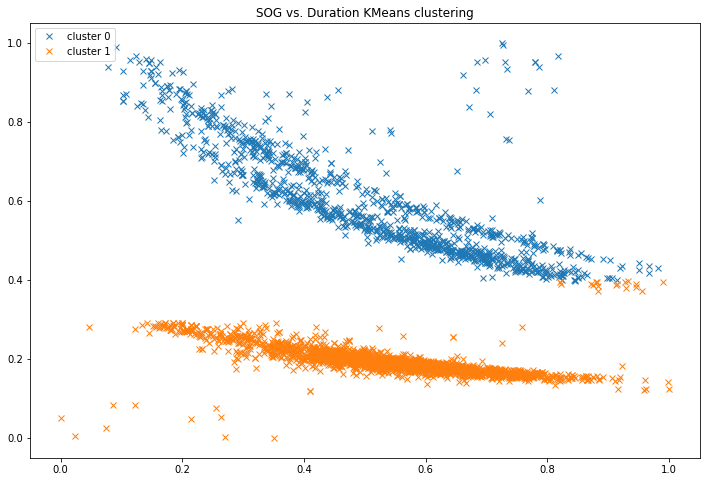

In [64]:
# Change the considered attributes

x = ['SOG', 'Duration'] # change

n = 

kmeans = KMeans(n_clusters = n, random_state = 1).fit(df[x])

plot_2att_clusters(df, 'SOG', 'Duration', kmeans.labels_)

__Which set of attributes gives the best clustering? Assign the value of__ ``x`` __to__ ``t23_att_selection`` __in the following cell. (2 points)__

In [51]:
# Best set of attributes (list of strings)

t23_att_selection = 

Most ML algorithms use some more advanced transformations of the data. We can add attributes which will be a combination of the other attributes in the dataset, to try to detect a better combination for the clustering model.

__Following the given example, try out a couple of combinations and build the clustering model for each one of them. Try to find a good combination.__

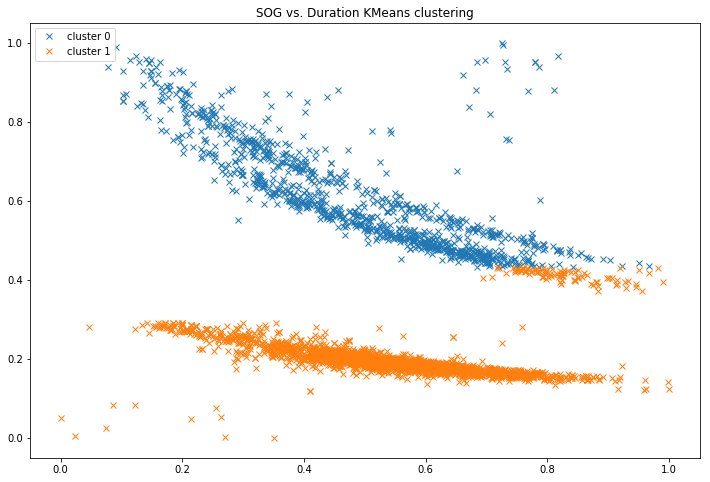

In [67]:
# Try combinations for attributes

df['Duration^2'] = df['Duration']*df['Duration'] # add other combinations

x = ['Duration', 'Duration^2'] # change

n = 

kmeans = KMeans(n_clusters = n, random_state = 1).fit(df[x])

plot_2att_clusters(df, 'SOG', 'Duration', kmeans.labels_)

_From the visualization, if you look at the gap between the 2 clusters according to each of the two attributes, which easy transformation can you think of to increase the performance of the clusterer?_

_On which shape of clusters would the SimpleKMeans algorithm perform the best?_

### 2.4 Hierarchical clustering: AgglomerativeClustering (10 min) <a class="anchor" id="t24"></a>

The hierarchical clustering algorithm:
* Assign a single cluster to each datapoint.
* Combine 2 clusters into one using a distance metric to select the closest clusters.
* Repeat to the root of the tree (until all the points form one big cluster): select the number of clusters to keep.

We continue using the same normalized dataset. This time, we apply the function ``AgglomerativeClustering``, to build a hierarchical clustering model (https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html). This function can be used the same way we used the KMeans algorithm, with the same parameters.

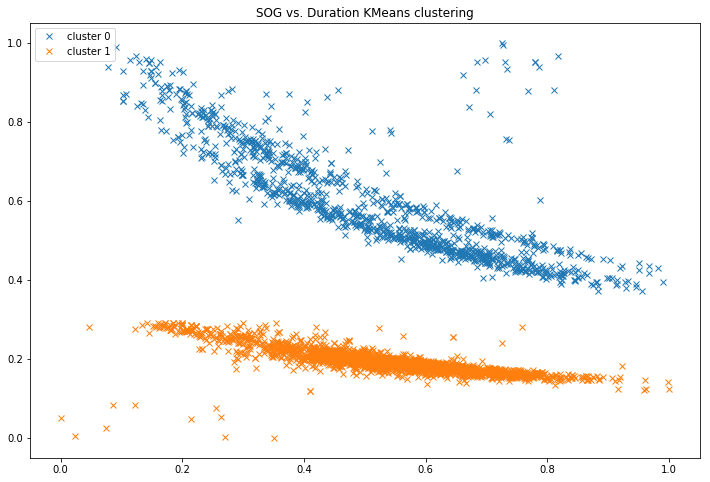

In [69]:
from sklearn.cluster import AgglomerativeClustering

x = ['SOG', 'Duration']

n = 

clustering = AgglomerativeClustering(n_clusters = n).fit(df[x])

plot_2att_clusters(df, 'SOG', 'Duration', clustering.labels_)

_How would you qualify this result after looking at the cluster assignments?_

_Why is this performance so much better than the KMeans algorithm on this dataset? (What was the problem of the dataset for the KMeans algorithm?)_